# 1D U-Net - Reduced Features (Raw HR + Session Context)

**Master's Thesis Implementation - Ablation Study**

Same 1D U-Net architecture as UNet_1D.ipynb, but with only 7 features instead of 39.
The model receives raw heart rate + session-level context and must learn all temporal patterns itself.

**Features used (7):** heart_rate, session_hr_mean, session_hr_std, session_hr_iqr, intervals_per_minute, expected_interval_length, is_high_density_session

Run all cells from top to bottom.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print("Imports complete")

TensorFlow version: 2.20.0
Imports complete


## 2. Configuration

In [2]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60
    
    # Post-processing
    peak_distance: int = 20
    peak_prominence: float = 0.15
    smooth_sigma: float = 3.0

    # U-Net specific
    segment_length: int = 300      # 5 minutes at 1Hz
    segment_overlap: int = 150     # 50% overlap for smoother probability averaging
    unet_epochs: int = 50
    unet_batch_size: int = 32
    unet_patience: int = 15
    unet_dropout: float = 0.25

CONFIG = Config()
print(f"Configuration set")

Configuration set


## 3. Data Configuration

In [3]:
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialRowing": {
        "sport": "rowing",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
        "allowed_files": "all"
    }
}

test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 4. Feature Engineering (Reduced: 7 features)

In [4]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:
    """Reduced feature set: raw HR + session-level context only.
    The model must learn all temporal patterns (derivatives, rolling stats, etc.) itself.
    """
    features = pd.DataFrame(index=df.index)
    hr = df['heart_rate'].values

    # Raw heart rate - the only temporal signal
    features['heart_rate'] = hr

    # Session-level context (constants per session)
    features['session_hr_mean'] = hr.mean()
    features['session_hr_std'] = hr.std()
    features['session_hr_iqr'] = np.percentile(hr, 75) - np.percentile(hr, 25)

    # Interval density features (session-level constants)
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()
        features['intervals_per_minute'] = n_expected_intervals / (session_duration / 60)
        features['expected_interval_length'] = session_duration / n_expected_intervals
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)

    # Clean up
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

print("Reduced feature engineering: 7 features (raw HR + session context)")

Reduced feature engineering: 7 features (raw HR + session context)


## 5. Post-Processing

In [5]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    if n_expected_intervals >= 50:
        peak_distance = 3
    elif n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    # Adaptive smoothing
    session_duration = len(probabilities)
    avg_interval_len = session_duration / n_expected_intervals
    if avg_interval_len < 60:
        sigma = 1.5
    elif avg_interval_len < 180:
        sigma = config.smooth_sigma
    else:
        sigma = 5.0

    probs_smooth = gaussian_filter1d(probabilities, sigma=sigma)

    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 6. Evaluation

In [6]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Bipartite greedy matching: closest pairs first, no double matching
    pairs = []
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                pairs.append((abs(time_diff), pred_idx, true_idx))

    pairs.sort()  # closest pairs first
    used_pred = set()
    used_true = set()
    matched_pairs = []

    for dist, pred_idx, true_idx in pairs:
        if pred_idx not in used_pred and true_idx not in used_true:
            matched_pairs.append((pred_idx, true_idx, dist))
            used_pred.add(pred_idx)
            used_true.add(true_idx)

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)
    n_matched = len(matched_pairs)

    precision = n_matched / n_pred if n_pred > 0 else 0
    recall = n_matched / n_true if n_true > 0 else 0

    beta = np.sqrt(2)
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # MAE: all predictions to nearest ground truth (unbounded)
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())
    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 7. Data Loading

In [7]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path): continue
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"  {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
    return session_data

print("Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\nLoaded {len(hr_session_data)} sessions total")

Loading session data...
  Athlete12 - 13609970768_Uffwrme
  Athlete12 - 14077735636_Base
  Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
  Athlete12 - 10694767945_Btchen_fahren_
  Athlete12 - 11636429453_4558_row
  Athlete12 - 13662882990_Heldentod
  Athlete12 - 10652950510_Btchen_fahren
  Athlete12 - 12036692734_Exhausted
  Athlete12 - 13610691264_1x_Crescendo
  Athlete12 - 13583093636_Afterburner_
  Athlete12 - 10543962115_10006_row
  Athlete12 - 13363035398_SGAktiv
  Athlete12 - 13974345688_Nochmaaaal
  Athlete12 - 13957096402_Technik
  Athlete12 - 11971395278_Use_it_or_lose_it
  Athlete12 - 12846436186_Synchronflug
  Athlete12 - 14125110656_Vallah_isch_balla
  Athlete12 - 14396237986_4659_row
  Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
  Athlete12 - 11962243206_Wundmanagement
  Athlete12 - 12069656901_Schwitzen_im_Sitzen
  Athlete12 - 13582048984_W_Up
  Athlete12 - 13280559542_Warm_up_rowing
  Athlete12 - 13601462878_Zehnbauer
  Athlete12 - 14313279747_Vernunft_ve

## 8. Prepare Train/Test Data

In [8]:
print("Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}
found_test_sessions = set()

for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()
    features_df = create_hr_features(df, CONFIG, n_intervals)
    X = features_df.values
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"  Skipping {session} - invalid values")
        continue
    sport = athletes[athlete]['sport']
    session_info = {
        'athlete': athlete, 'session': session, 'sport': sport,
        'X': X, 'y': y, 'n_intervals': n_intervals,
        'duration_sec': len(y), 'feature_names': features_df.columns.tolist(), 'df': df
    }
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

missing_test_sessions = set(test_sessions) - found_test_sessions
if missing_test_sessions:
    print("\nWARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        print(f"   {athlete}: {session}")
else:
    print("\nAll test sessions found successfully")

X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

offset = 0
for session in train_sessions:
    n = len(session['y'])
    session['X'] = X_train[offset:offset+n]
    offset += n

print(f"\nDataset prepared:")
print(f"   Training: {len(train_sessions)} (Biking: {train_sport_count['biking']}, Rowing: {train_sport_count['rowing']})")
print(f"   Test: {len(test_sessions_data)} (Biking: {test_sport_count['biking']}, Rowing: {test_sport_count['rowing']})")
print(f"   Samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")

Preparing train/test datasets...

   Athlete12: 12989160676_Wohnzimmerromantik

Dataset prepared:
   Training: 75 (Biking: 24, Rowing: 51)
   Test: 18 (Biking: 6, Rowing: 12)
   Samples: 278,990 (1428 positive)
   Features: 7


## 9. Prepare U-Net Segments

In [9]:
def prepare_segments(sessions, seg_len, overlap):
    """Create overlapping segments for training."""
    all_X, all_y = [], []
    stride = seg_len - overlap
    for s in sessions:
        X, y = s['X'], s['y']
        for i in range((len(X) - seg_len) // stride + 1):
            start = i * stride
            end = start + seg_len
            if end <= len(X):
                all_X.append(X[start:end])
                all_y.append(y[start:end])
    return np.array(all_X), np.array(all_y)

# Session-level validation split (~15% of training sessions)
np.random.seed(CONFIG.random_seed)
n_val = max(1, int(len(train_sessions) * 0.15))
np.random.shuffle(train_sessions)
val_sessions = train_sessions[:n_val]
actual_train_sessions = train_sessions[n_val:]

X_train_seg, y_train_seg = prepare_segments(actual_train_sessions, CONFIG.segment_length, CONFIG.segment_overlap)
X_val_seg, y_val_seg = prepare_segments(val_sessions, CONFIG.segment_length, CONFIG.segment_overlap)

y_train_seg = y_train_seg[..., np.newaxis]
y_val_seg = y_val_seg[..., np.newaxis]

n_features = X_train_seg.shape[2]
print(f"Train segments: {X_train_seg.shape}")
print(f"Val segments: {X_val_seg.shape}")
print(f"Train positive: {y_train_seg.sum():.0f}/{y_train_seg.size} ({y_train_seg.sum()/y_train_seg.size*100:.3f}%)")
print(f"Val sessions: {n_val}, Train sessions: {len(actual_train_sessions)}")

Train segments: (1489, 300, 7)
Val segments: (271, 300, 7)
Train positive: 2011/446700 (0.450%)
Val sessions: 11, Train sessions: 64


## 10. Build 1D U-Net Model

In [10]:
def conv_block(x, filters, dropout_rate):
    """Double convolution block: Conv1D -> BN -> ReLU -> Conv1D -> BN -> ReLU -> Dropout"""
    reg = keras.regularizers.l2(1e-4)
    x = layers.Conv1D(filters, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(filters, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def build_unet_1d(input_shape, dropout_rate=0.25):
    """Build 1D U-Net for time series segmentation.
    
    Architecture:
      Encoder: 3 levels with filters [32, 64, 128], pool sizes [2, 2, 3]
      Bottleneck: 256 filters at temporal resolution 25
      Decoder: 3 levels mirroring encoder with skip connections
      Output: sigmoid activation for per-timestep boundary probability
    
    Temporal path: 300 -> 150 -> 75 -> 25 (bottleneck) -> 75 -> 150 -> 300
    """
    inputs = layers.Input(shape=input_shape)
    
    # ---- Encoder ----
    e1 = conv_block(inputs, 32, dropout_rate)
    p1 = layers.MaxPooling1D(2)(e1)
    
    e2 = conv_block(p1, 64, dropout_rate)
    p2 = layers.MaxPooling1D(2)(e2)
    
    e3 = conv_block(p2, 128, dropout_rate)
    p3 = layers.MaxPooling1D(3)(e3)
    
    # ---- Bottleneck ----
    b = conv_block(p3, 256, dropout_rate)
    
    # ---- Decoder ----
    u3 = layers.UpSampling1D(3)(b)
    u3 = layers.Concatenate()([u3, e3])
    d3 = conv_block(u3, 128, dropout_rate)
    
    u2 = layers.UpSampling1D(2)(d3)
    u2 = layers.Concatenate()([u2, e2])
    d2 = conv_block(u2, 64, dropout_rate)
    
    u1 = layers.UpSampling1D(2)(d2)
    u1 = layers.Concatenate()([u1, e1])
    d1 = conv_block(u1, 32, dropout_rate)
    
    # ---- Output ----
    outputs = layers.Conv1D(1, 1, activation='sigmoid')(d1)
    
    model = keras.Model(inputs, outputs)
    return model


model = build_unet_1d(
    input_shape=(CONFIG.segment_length, n_features),
    dropout_rate=CONFIG.unet_dropout
)
model.summary()

pos_weight = (y_train_seg.size - y_train_seg.sum()) / max(y_train_seg.sum(), 1)

def weighted_bce(y_true, y_pred):
    bce = keras.backend.binary_crossentropy(y_true, y_pred)
    weight_map = y_true * (pos_weight - 1) + 1
    return keras.backend.mean(bce * weight_map)

model.compile(optimizer=keras.optimizers.Adam(0.001), loss=weighted_bce, metrics=['accuracy'])
print(f"\nLoss: Weighted BCE (pos_weight={pos_weight:.1f})")
print(f"Dropout: {CONFIG.unet_dropout} | L2: 1e-4")
print(f"Temporal path: 300 -> 150 -> 75 -> 25 (bottleneck) -> 75 -> 150 -> 300")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 7)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 32)   │        704 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 32)   │      3,104 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 300, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300, 32)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 32)   │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 150, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 150, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 150, 64)   │     12,352 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 150, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 150, 64)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 75, 64)    │          0 │ dropout_1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 75, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 75, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 75, 128)   │     49,280 │ re_lu_4[0][0]   

 Total params: 655,937 (2.50 MB)

 Trainable params: 653,121 (2.49 MB)

 Non-trainable params: 2,816 (11.00 KB)


Loss: Weighted BCE (pos_weight=221.1)
Dropout: 0.25 | L2: 1e-4
Temporal path: 300 -> 150 -> 75 -> 25 (bottleneck) -> 75 -> 150 -> 300


## 11. Train Model

Training 1D U-Net (reduced features)...
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 352ms/step - accuracy: 0.5103 - loss: 1.4463 - val_accuracy: 0.5954 - val_loss: 1.9266 - learning_rate: 0.0010
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 316ms/step - accuracy: 0.7099 - loss: 1.2995 - val_accuracy: 0.7260 - val_loss: 1.8648 - learning_rate: 0.0010
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 295ms/step - accuracy: 0.7324 - loss: 1.2571 - val_accuracy: 0.6898 - val_loss: 1.7734 - learning_rate: 0.0010
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 285ms/step - accuracy: 0.7457 - loss: 1.2111 - val_accuracy: 0.6738 - val_loss: 1.6933 - learning_rate: 0.0010
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.7285 - loss: 1.1555 - val_accuracy: 0.6332 - val_loss: 1.5904 - learning_rate: 0.0010
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 319ms/step - accuracy: 0.7558 - loss: 1.0720 - val_accuracy: 0.6576 - val_loss: 1.4321 - learning_rate: 0.0010
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 

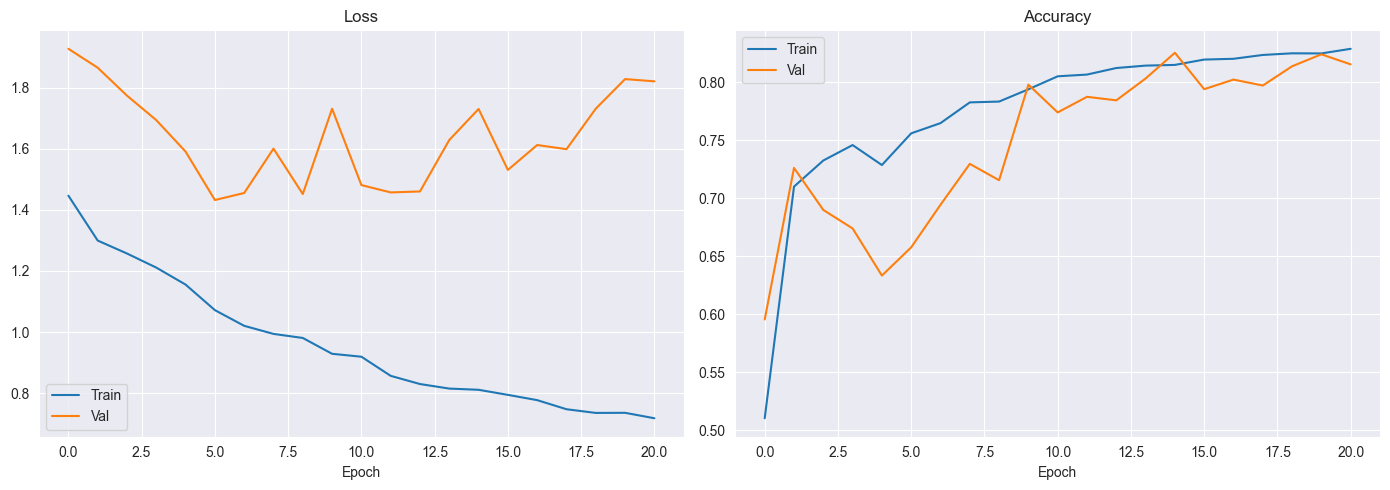

Trained for 21 epochs


In [11]:
print("Training 1D U-Net (reduced features)...")
history = model.fit(
    X_train_seg, y_train_seg,
    epochs=CONFIG.unet_epochs,
    batch_size=CONFIG.unet_batch_size,
    validation_data=(X_val_seg, y_val_seg),
    callbacks=[
        EarlyStopping('val_loss', patience=CONFIG.unet_patience, restore_best_weights=True),
        ReduceLROnPlateau('val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train'); ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'], label='Train'); ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Trained for {len(history.history['loss'])} epochs")

## 12. Evaluate on Test Sessions

In [12]:
def predict_session_unet(model, session, seg_len, overlap):
    """Predict on a full session by stitching overlapping segments."""
    X = session['X']
    pred_sum = np.zeros(len(X))
    pred_cnt = np.zeros(len(X))
    stride = seg_len - overlap

    for i in range((len(X) - seg_len) // stride + 1):
        start = i * stride
        end = start + seg_len
        if end <= len(X):
            segment = X[start:end].reshape(1, seg_len, -1)
            pred = model.predict(segment, verbose=0)[0, :, 0]
            pred_sum[start:end] += pred
            pred_cnt[start:end] += 1

    if pred_cnt[-1] == 0 and len(X) >= seg_len:
        start = len(X) - seg_len
        segment = X[start:].reshape(1, seg_len, -1)
        pred = model.predict(segment, verbose=0)[0, :, 0]
        pred_sum[start:] += pred
        pred_cnt[start:] += 1

    return np.divide(pred_sum, pred_cnt, where=pred_cnt > 0)


print("Evaluating on test sessions...\n")

test_results = []
for session_info in test_sessions_data:
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    y_pred_proba = predict_session_unet(model, session_info, CONFIG.segment_length, CONFIG.segment_overlap)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)

    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics.update({'session': session_info['session'], 'athlete': session_info['athlete'],
                    'y_true': y_true, 'y_pred': y_pred, 'y_pred_proba': y_pred_proba, 'df': session_info['df']})
    test_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

avg = {k: np.mean([r[k] for r in test_results]) for k in ['f_beta', 'precision', 'recall', 'mean_error_sec']}

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg['f_beta']:.3f}")
print(f"  Precision: {avg['precision']:.3f}")
print(f"  Recall:    {avg['recall']:.3f}")
print(f"  Avg Error: {avg['mean_error_sec']:.1f} seconds")
print("="*70)

Evaluating on test sessions...

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.444 | P: 0.444 | R: 0.444 | Error: 62.4s
   Intervals: 9/9

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 0.667 | P: 0.667 | R: 0.667 | Error: 98.3s
   Intervals: 3/3

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.727 | P: 0.727 | R: 0.727 | Error: 22.5s
   Intervals: 11/11

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.500 | P: 0.500 | R: 0.500 | Error: 53.3s
   Intervals: 12/12

Athlete12    | 12069656901_Schwitzen_im_Sitze
   F_beta(2:1): 0.286 | P: 0.286 | R: 0.286 | Error: 81.3s
   Intervals: 7/7

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.667 | P: 0.667 | R: 0.667 | Error: 41.9s
   Intervals: 9/9

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.444 | P: 0.444 | R: 0.444 | Error: 52.6s
   Intervals: 9/9

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.700 | P: 0.700 | R: 0.700 | Erro

## 13. Visualize All Test Sessions

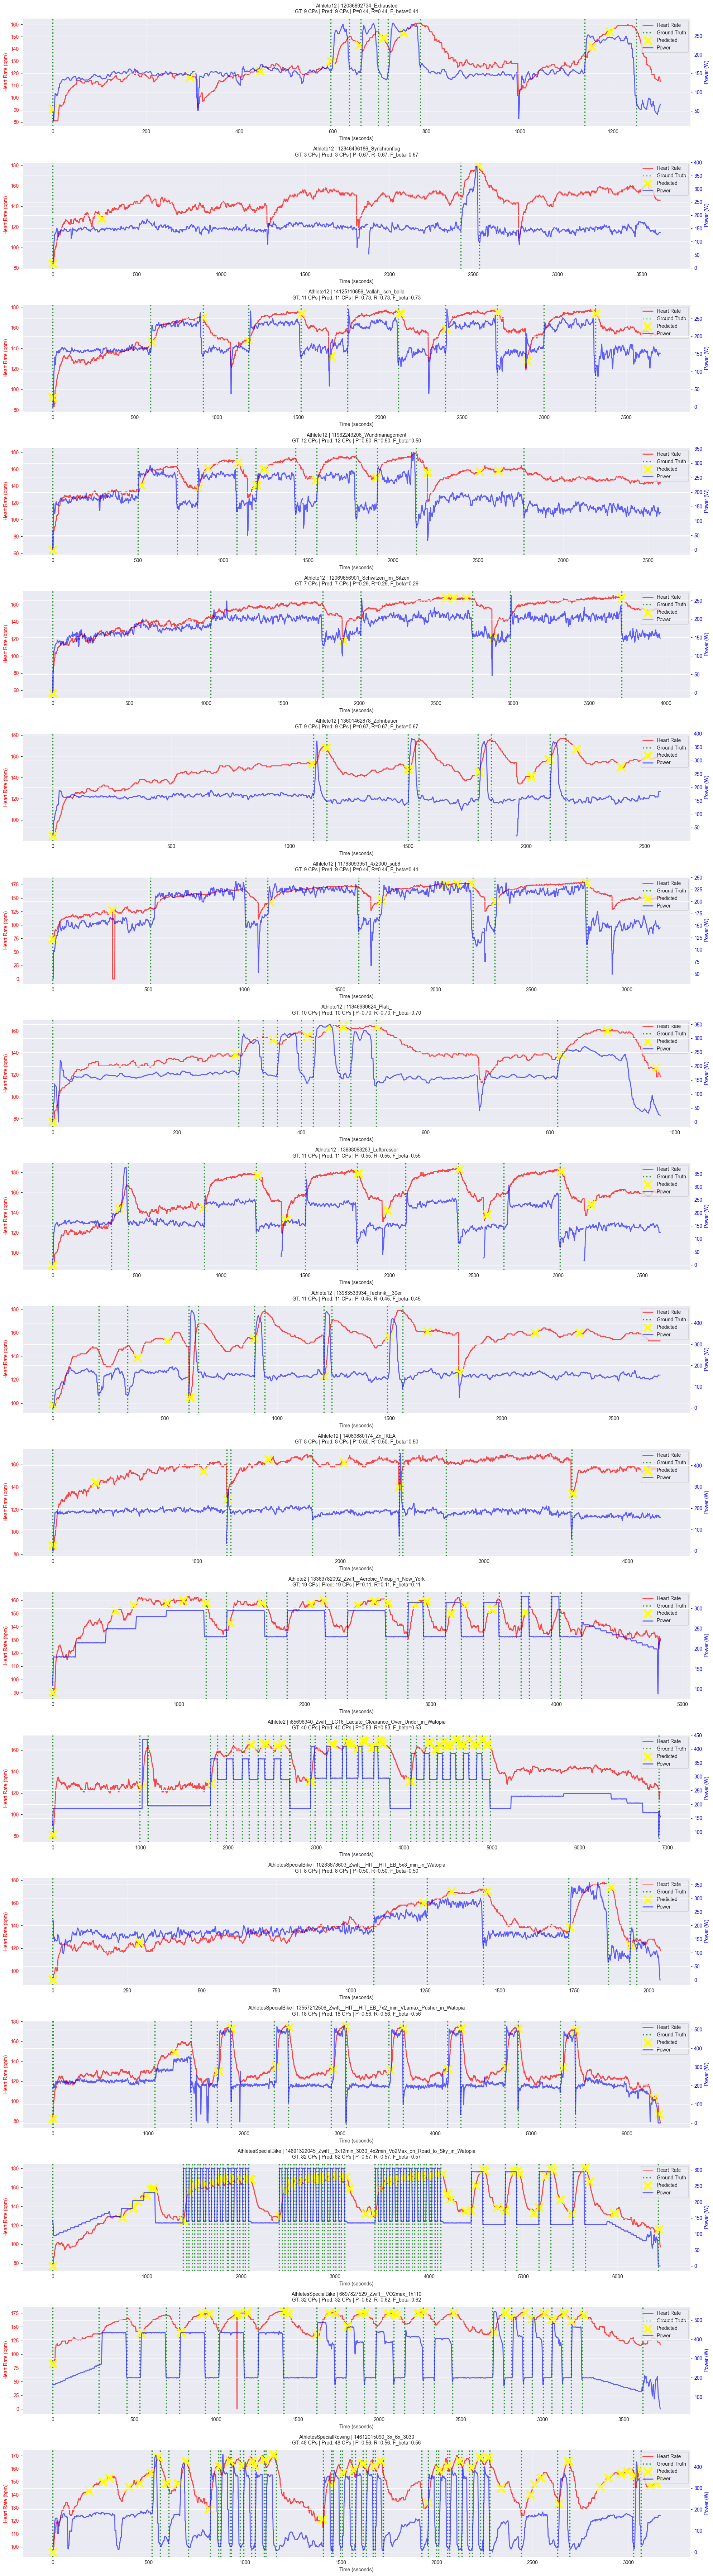

In [13]:
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))
if n_sessions == 1: axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    hr_values = df['heart_rate'].values
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    if 'power' in df.columns:
        ax2.plot(df['power'].values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    gt_cps = np.where(result['y_true'] == 1)[0]
    pred_cps = np.where(result['y_pred'] == 1)[0]

    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5, alpha=0.8, zorder=4,
                       label='Ground Truth' if cp == gt_cps[0] else '')

    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow', linewidths=4, zorder=5,
                       label='Predicted' if cp == pred_cps[0] else '')

    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics

Results: 18 test sessions
  rowing: 12 sessions
  biking: 6 sessions


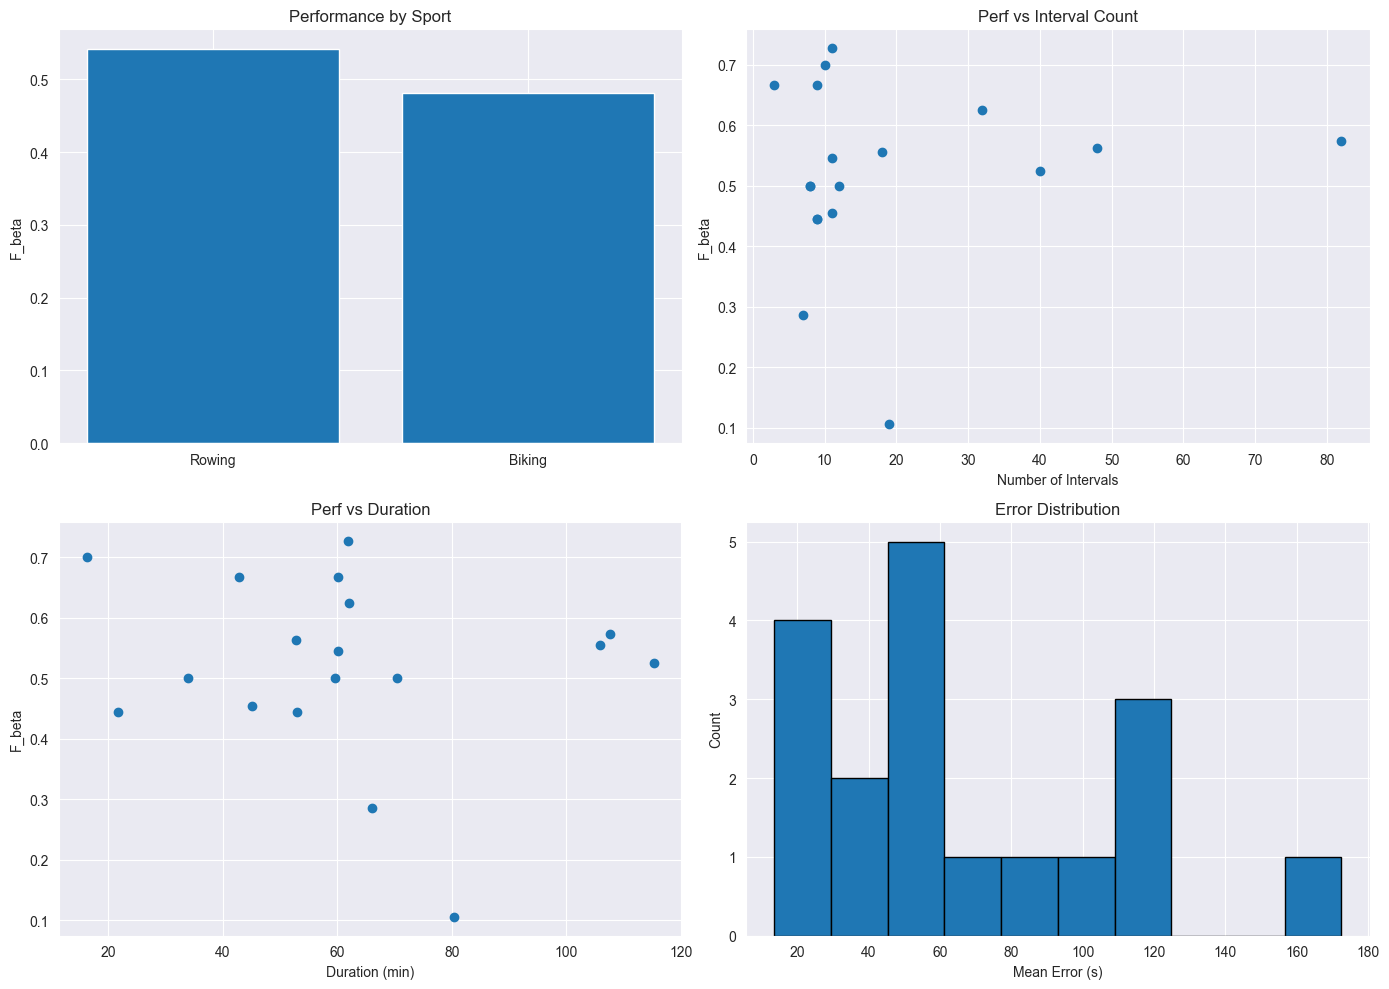

In [14]:
athlete_sport_mapping = {k: v['sport'] for k, v in athletes.items()}
df_results = pd.DataFrame([{
    'athlete': r['athlete'], 'session': r['session'], 'n_intervals': r['n_true'], 'n_pred': r['n_pred'],
    'f_beta': r['f_beta'], 'precision': r['precision'], 'recall': r['recall'],
    'mean_error_sec': r['mean_error_sec'], 'duration_min': len(r['y_true']) / 60,
    'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
} for r in test_results])

print(f"Results: {len(df_results)} test sessions")
for sport, count in df_results['sport'].value_counts().items():
    print(f"  {sport}: {count} sessions")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].bar(['Rowing','Biking'], [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
              df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0,0].set_ylabel('F_beta'); axes[0,0].set_title('Performance by Sport')
axes[0,1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0,1].set_xlabel('Number of Intervals'); axes[0,1].set_ylabel('F_beta'); axes[0,1].set_title('Perf vs Interval Count')
axes[1,0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1,0].set_xlabel('Duration (min)'); axes[1,0].set_ylabel('F_beta'); axes[1,0].set_title('Perf vs Duration')
axes[1,1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1,1].set_xlabel('Mean Error (s)'); axes[1,1].set_ylabel('Count'); axes[1,1].set_title('Error Distribution')
plt.tight_layout()
plt.show()

## 15. Save Results

In [15]:
import pickle
with open('results/unet_1d_reduced_results.pkl', 'wb') as f:
    pickle.dump({'model_name': 'UNet_1D_ReducedFeatures', 'results': test_results}, f)
print(f"Saved {len(test_results)} U-Net (Reduced Features) results")

Saved 18 U-Net (Reduced Features) results
